In [ ]:
!pip install snowflake pandas sci-kit

In [ ]:
import snowflake.connector
import pandas as pd

In [ ]:
con=snowflake.connector.connect(
    user='Shivaji',
    password='Shivaji11042007',
    account='PLFONYJ-PV16555',
    database='churn',
    schema="PUBLIC",
    warehouse='COMPUTE_WH'
)

In [ ]:
query='select * from churndb'
df=pd.read_sql(query,con)

/tmp/ipykernel_4863/602285727.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,con)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ROWNUMBER        10000 non-null  int64  
 1   CUSTOMERID       10000 non-null  int64  
 2   SURNAME          10000 non-null  object 
 3   CREDITSCORE      10000 non-null  int64  
 4   GEOGRAPHY        10000 non-null  object 
 5   GENDER           10000 non-null  object 
 6   AGE              10000 non-null  int64  
 7   TENURE           10000 non-null  int64  
 8   BALANCE          10000 non-null  float64
 9   NUMOFPRODUCTS    10000 non-null  int64  
 10  HASCRCARD        10000 non-null  int64  
 11  ISACTIVEMEMBER   10000 non-null  int64  
 12  ESTIMATEDSALARY  10000 non-null  float64
 13  EXITED           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.isnull().sum(

)

,0
ROWNUMBER,0
CUSTOMERID,0
SURNAME,0
CREDITSCORE,0
GEOGRAPHY,0
GENDER,0
AGE,0
TENURE,0
BALANCE,0
NUMOFPRODUCTS,0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

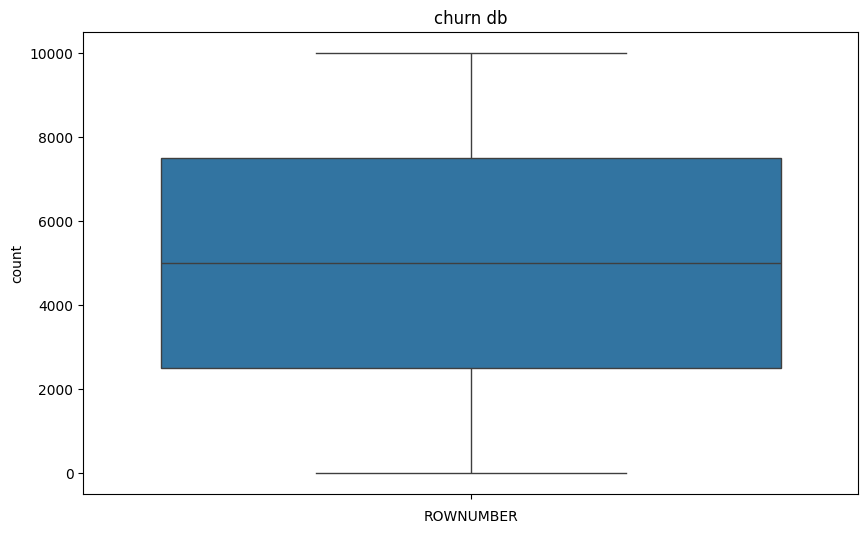

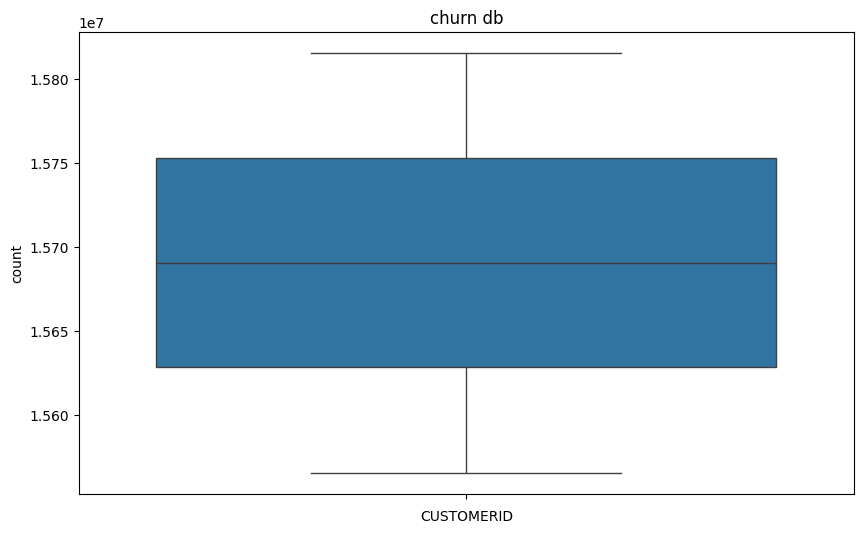

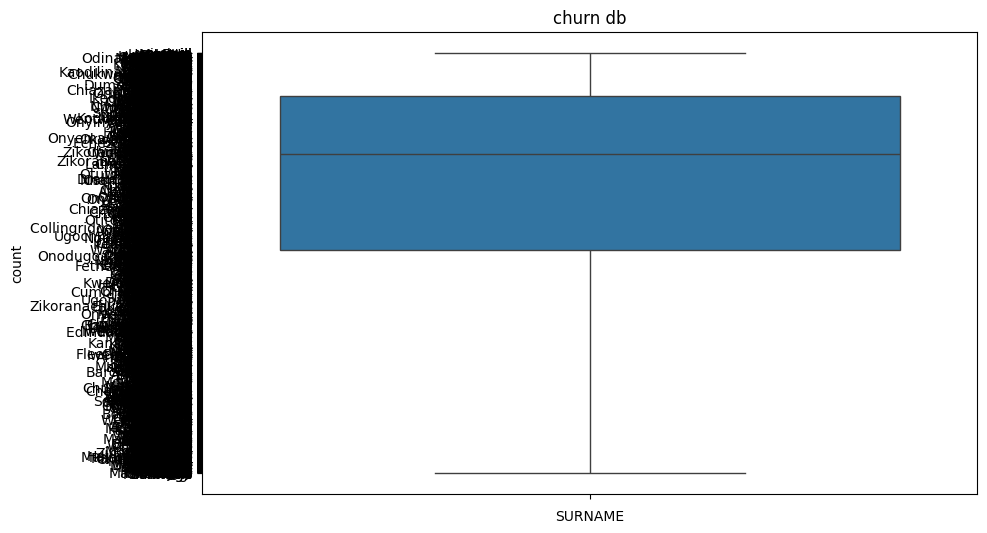

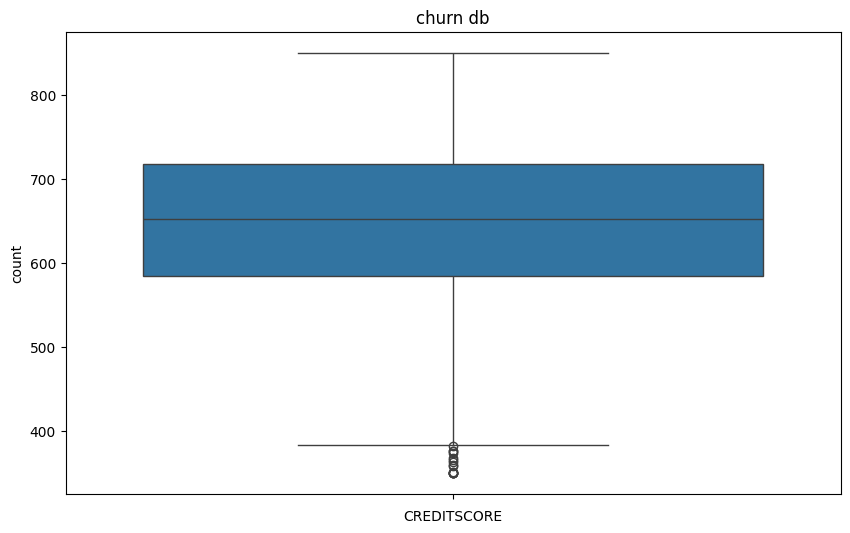

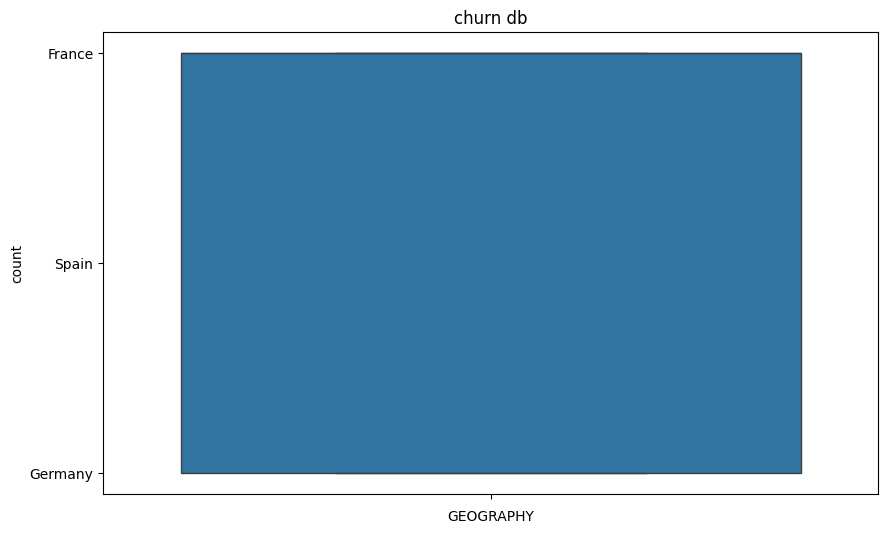

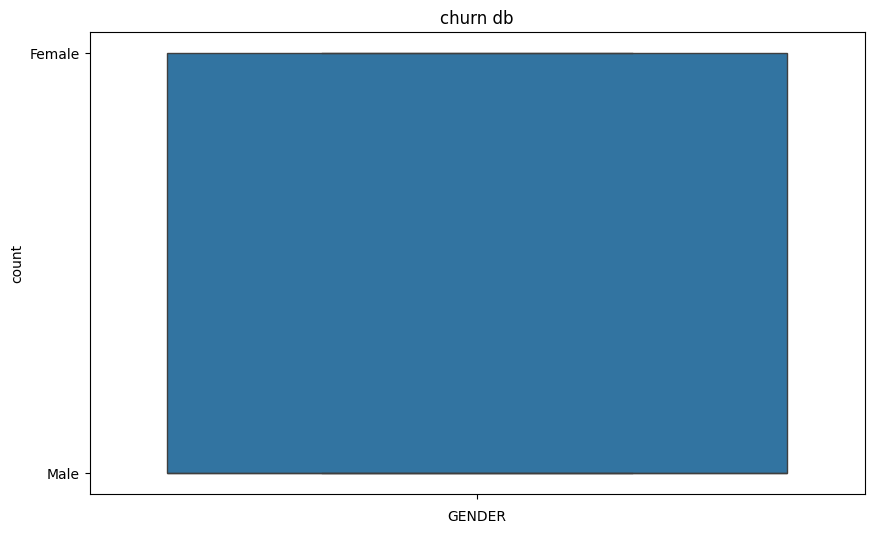

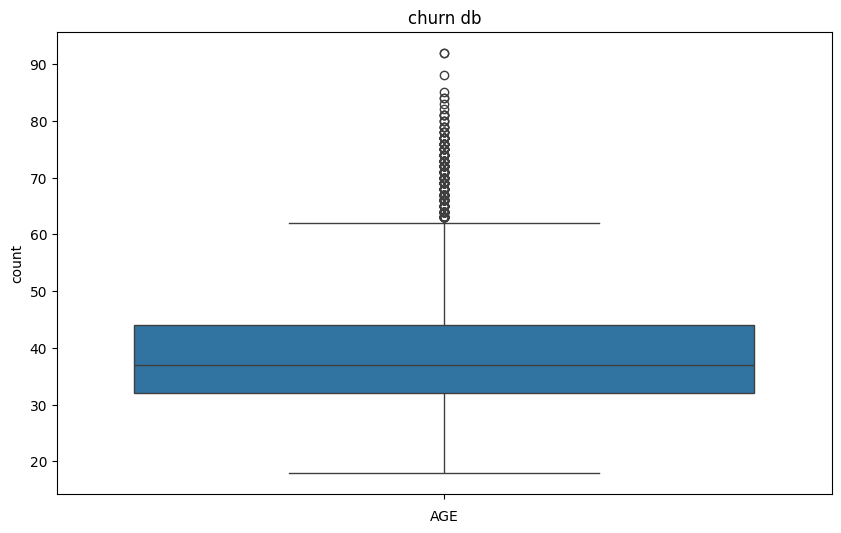

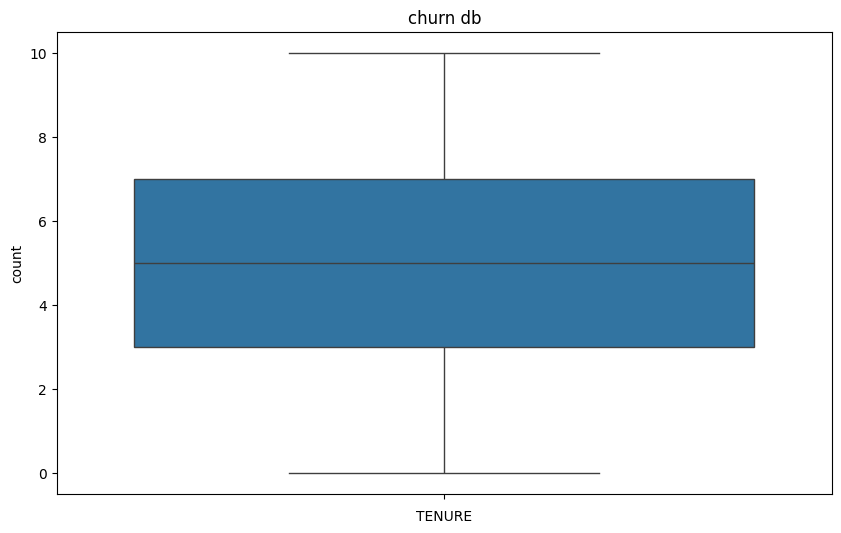

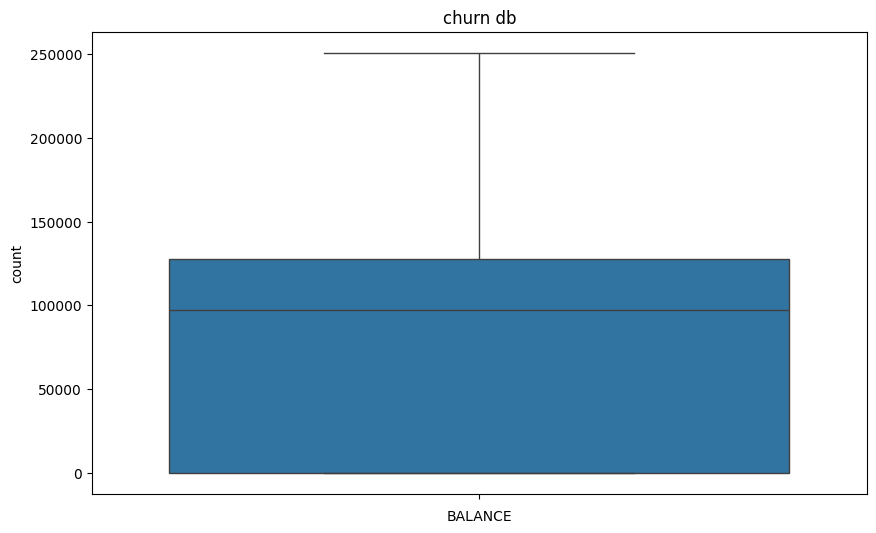

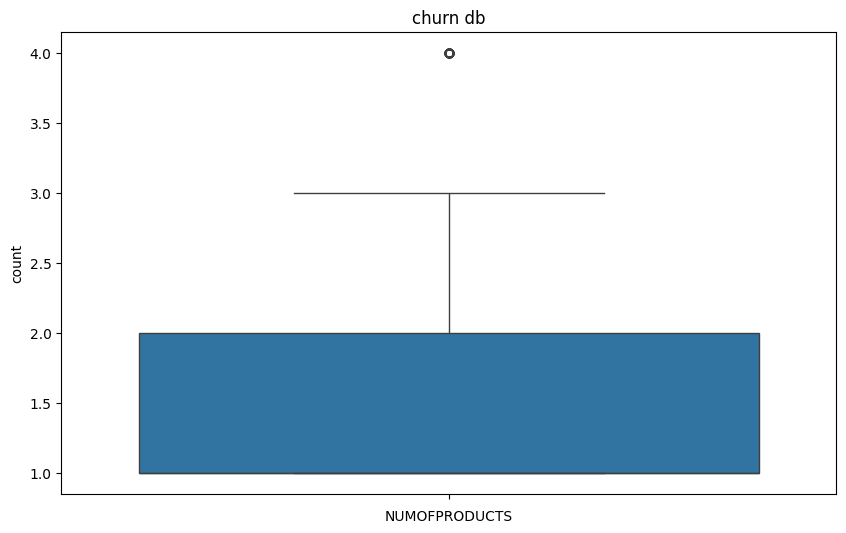

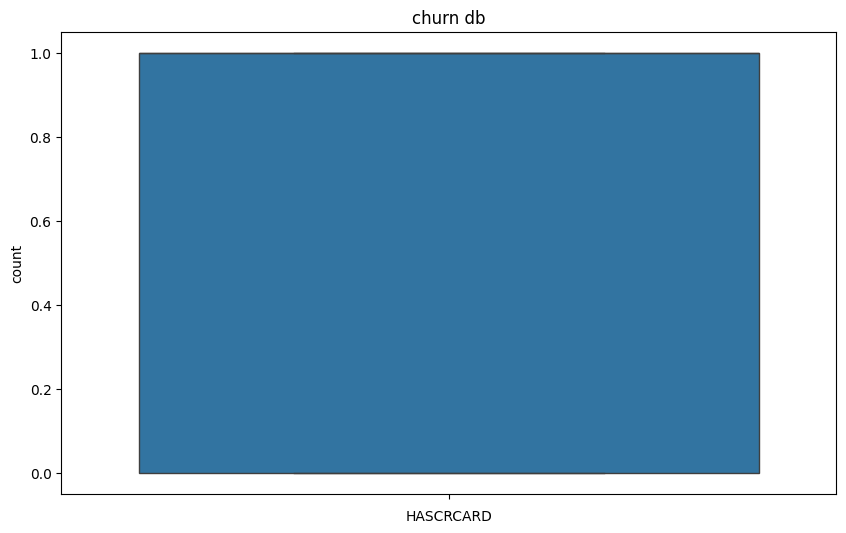

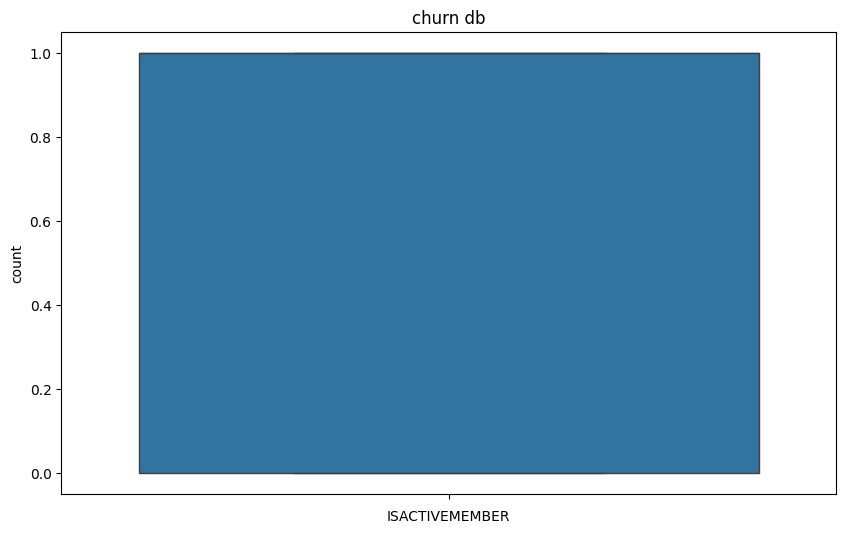

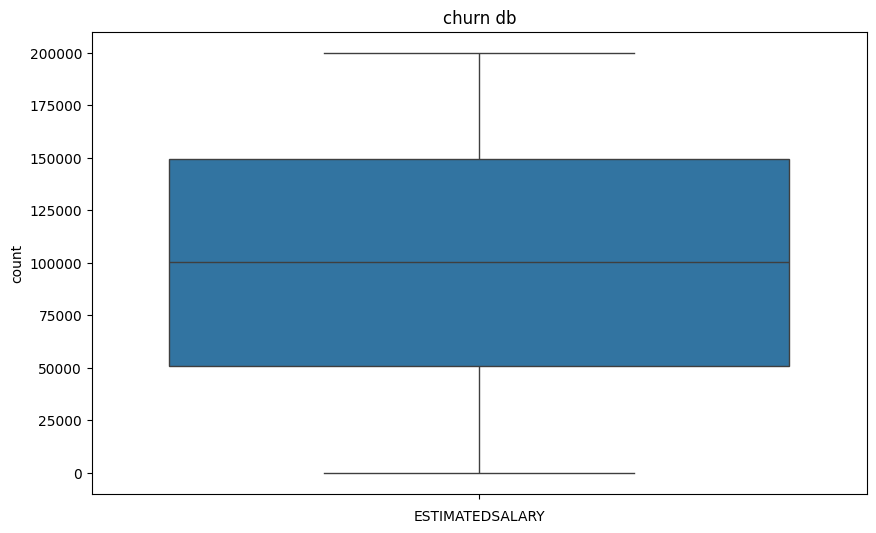

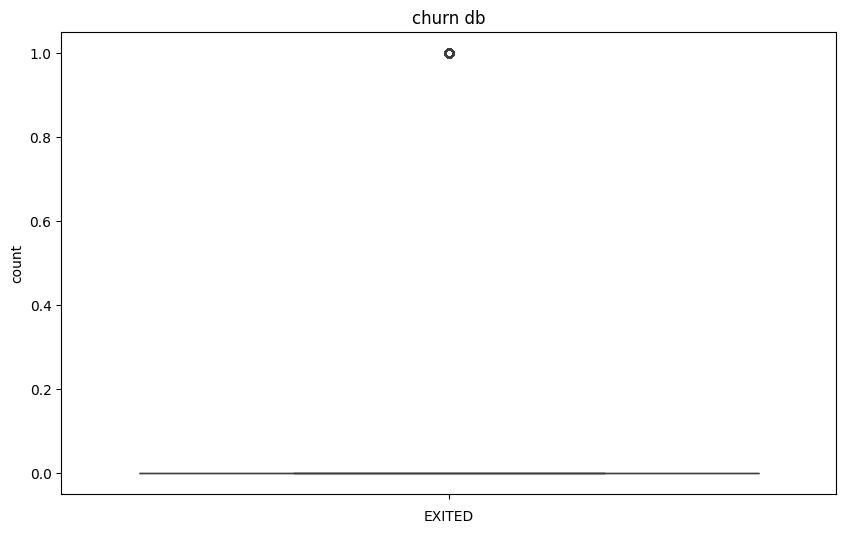

In [ ]:
for i in df.columns:
  if df[i].dtypes != "objects":
    plt.figure(figsize=(10,6))
    sns.boxplot(df[i])
    plt.title("churn db")
    plt.xlabel(i)
    plt.ylabel("count")
    plt.show()

In [ ]:
out=['CREDITSCORE','AGE','NUMOFPRODUCTS']

In [ ]:
for i in out:
  Q1=df[i].quantile(0.25)
  Q3=df[i].quantile(0.75)
  IQR=Q3-Q1

  lb = Q1 - 1.5*IQR
  ub = Q3 + 1.5*IQR

  df=df[(lb<=df[i]) & (ub>=df[i])]

In [ ]:
for i in out:
  Q1=df[i].quantile(0.25)
  Q3=df[i].quantile(0.75)
  IQR=Q3-Q1

  lb = Q1 - 1.5*IQR
  ub = Q3 + 1.5*IQR

  df=df[(lb<=df[i]) & (ub>=df[i])]

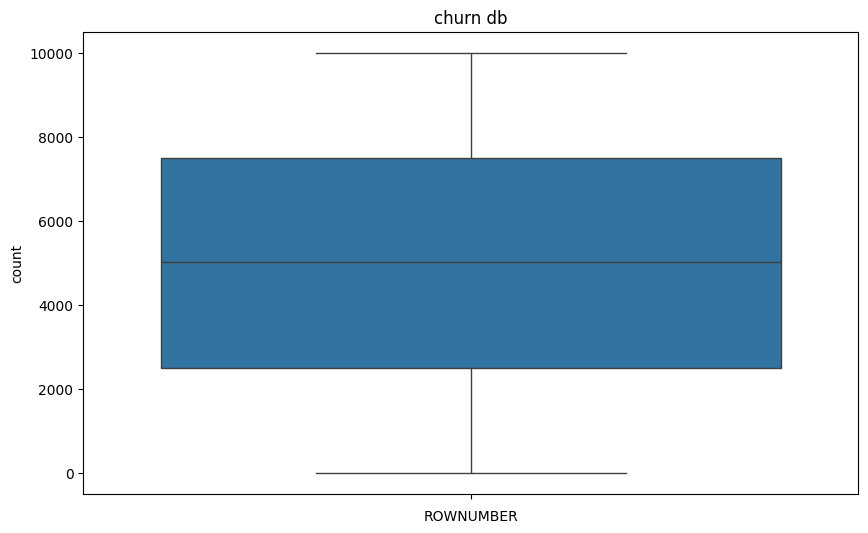

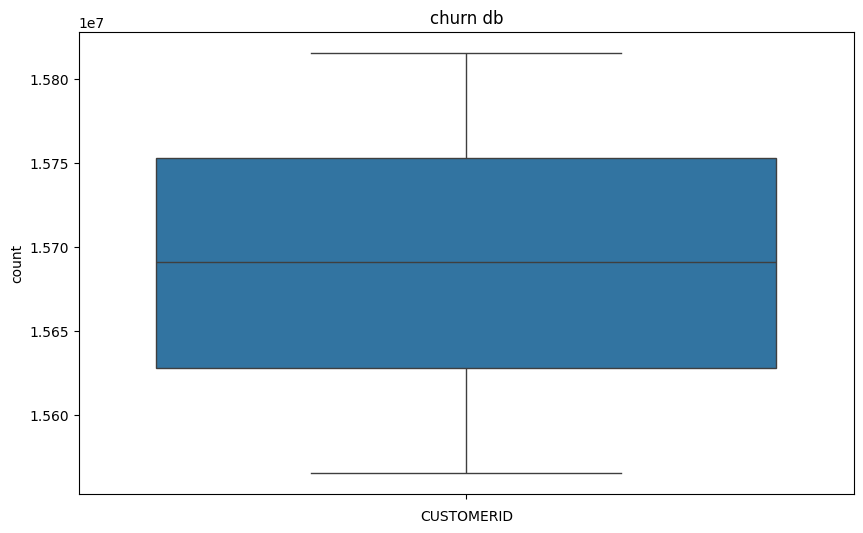

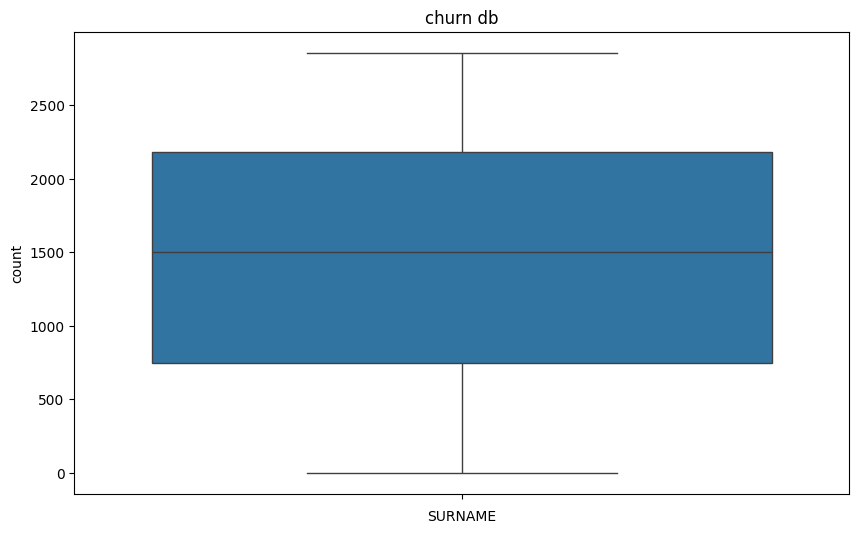

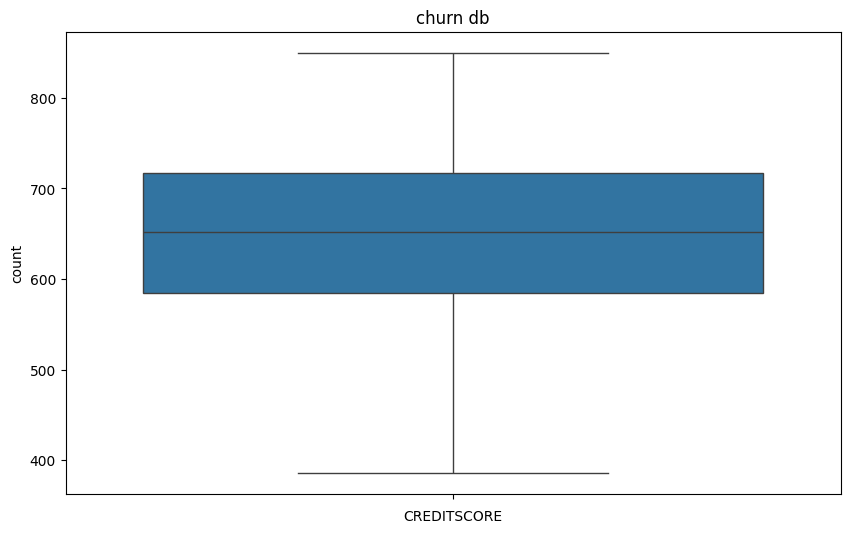

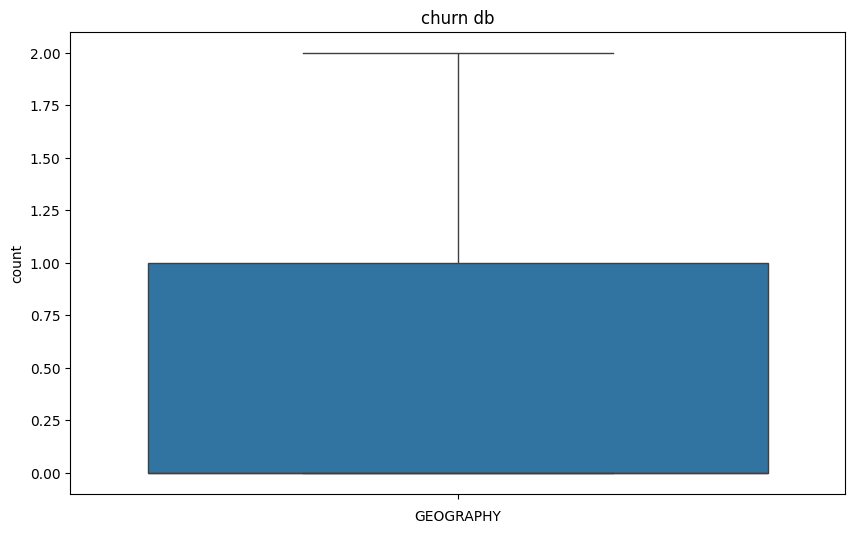

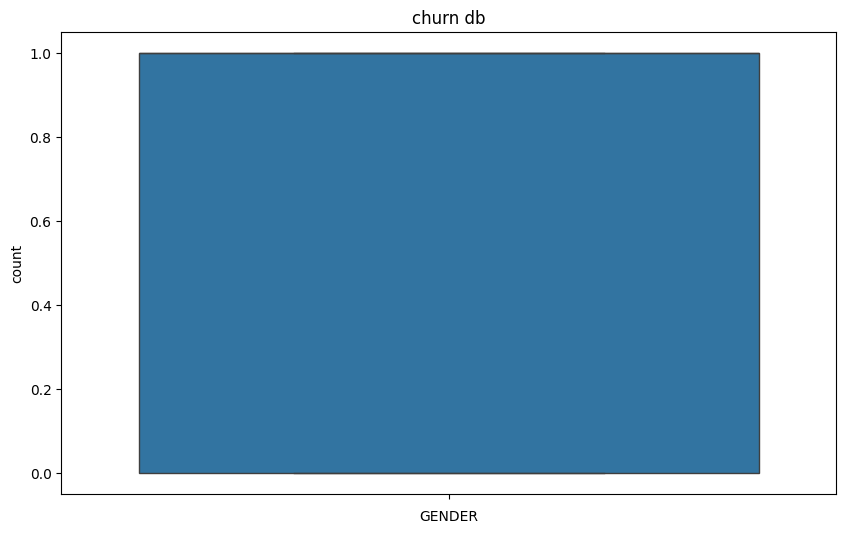

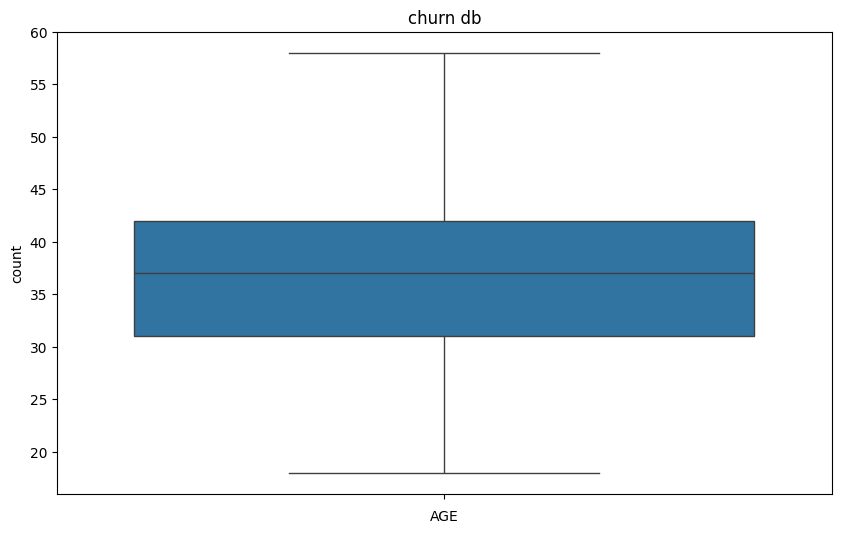

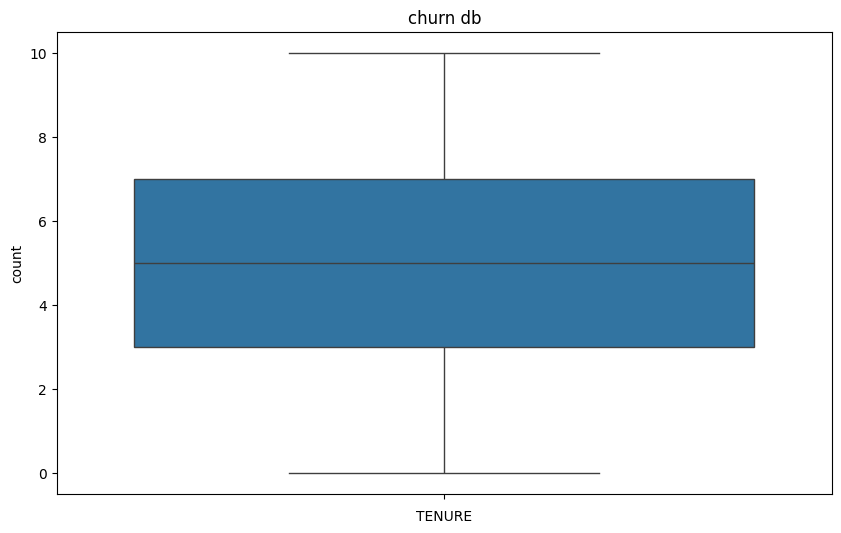

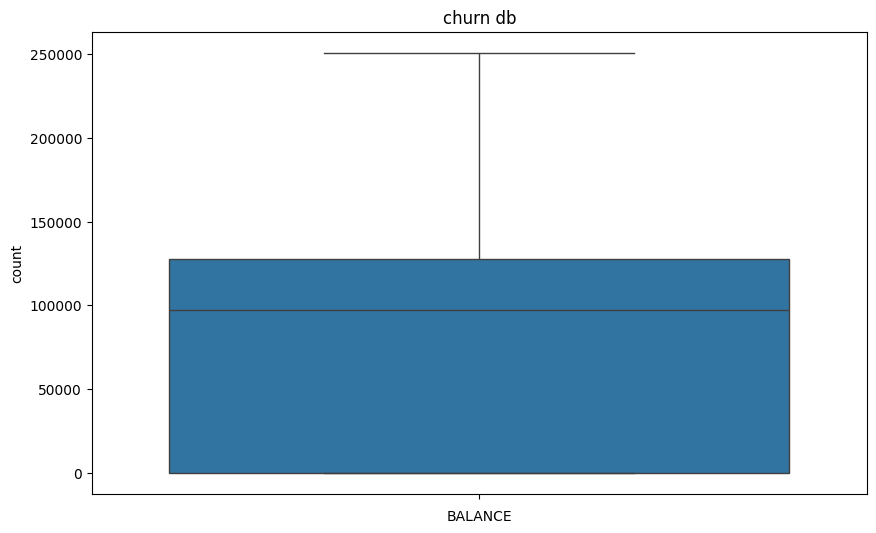

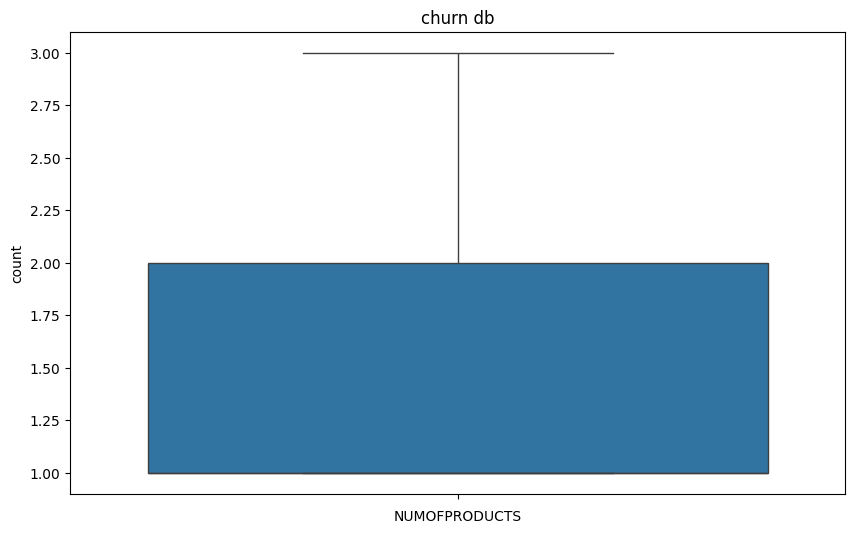

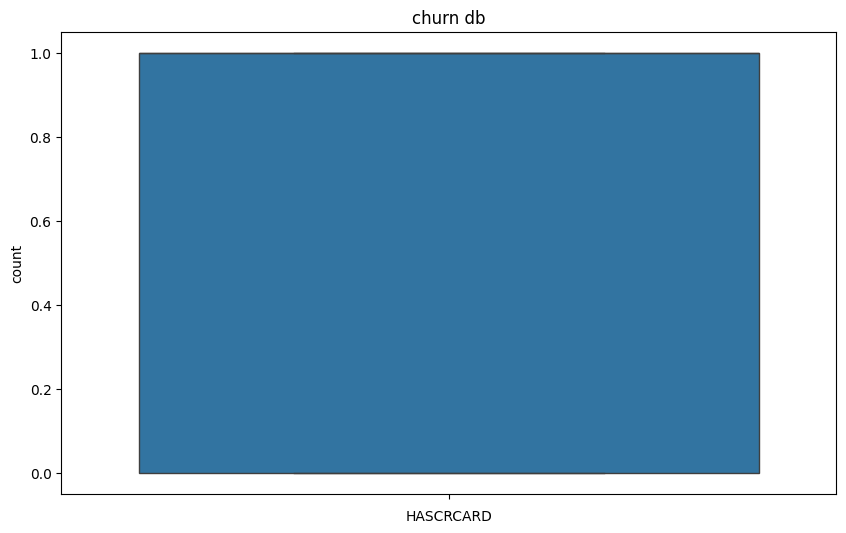

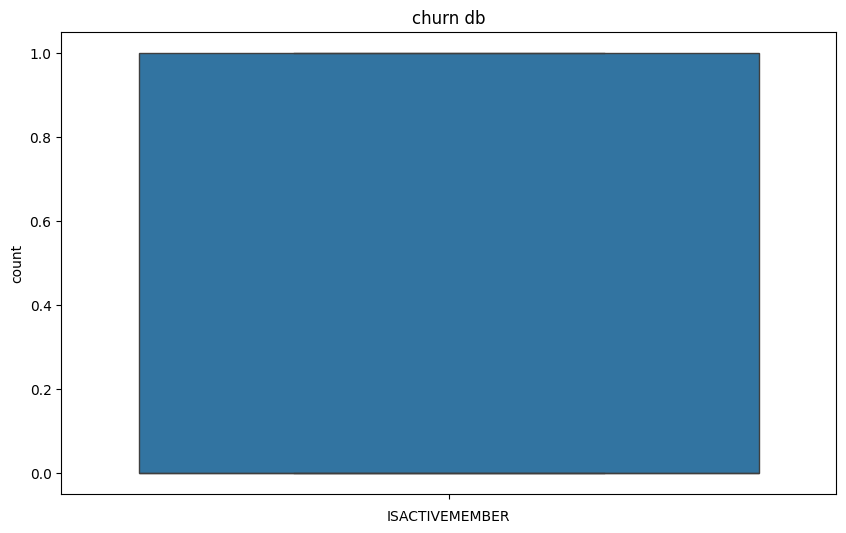

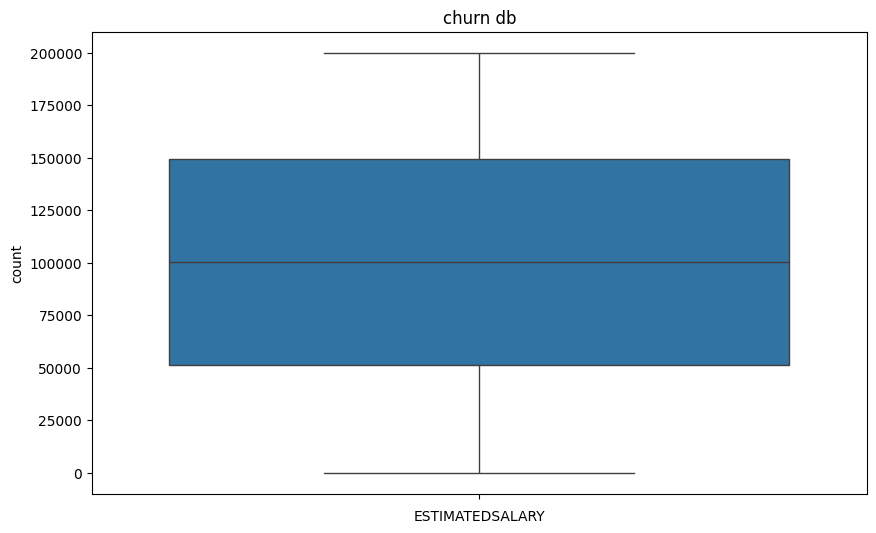

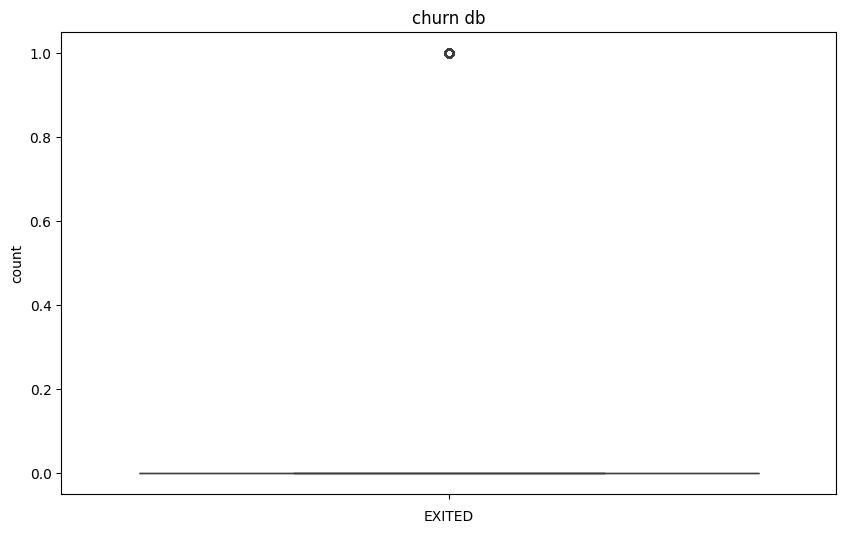

In [ ]:
for i in df.columns:
  if df[i].dtypes != "objects":
    plt.figure(figsize=(10,6))
    sns.boxplot(df[i])
    plt.title("churn db")
    plt.xlabel(i)
    plt.ylabel("count")
    plt.show()

In [ ]:
from sklearn.preprocessing import  LabelEncoder
le=LabelEncoder()
for i in df.columns:
  if df[i].dtypes == "object":
    df[i]=le.fit_transform(df[i])

In [ ]:
df

,ROWNUMBER,CUSTOMERID,SURNAME,CREDITSCORE,GEOGRAPHY,GENDER,AGE,TENURE,BALANCE,NUMOFPRODUCTS,HASCRCARD,ISACTIVEMEMBER,ESTIMATEDSALARY,EXITED
0,1,15634602,1092,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,1152,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,1993,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,284,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,1780,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,1952,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,1309,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,1535,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,2286,772,1,1,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x=df.iloc[:,:-1]
y=df["EXITED"]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.naive_bayes import BernoulliNB


In [ ]:
nb=BernoulliNB()
nb.fit(x_train,y_train)
y_pred=nb.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score


In [ ]:
print("Accuracy Score",accuracy_score(y_pred,y_test)*100)

Accuracy Score 80.36383092562868
